### Libraries.

In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
from tqdm import tqdm

from sc_exp_design.data import DataManager, SequentialDataLoader
from sc_exp_design.networks import MLPBlock, MLPGaussianNoiseModel


### Reading the data.


In [3]:
PATH = "../../../theis/HID01_fcs_concatenated.h5ad"
adata = sc.read_h5ad(PATH)
adata


AnnData object with n_obs × n_vars = 93278696 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Subsampling the data.

In [4]:
# optionally subsample the data
KEEP_COPY = True
SUBSAMPLE = True
SUBSAMPLING_DONE = False
SUBSAMPLE_SIZE = 1e-2

if SUBSAMPLE and not SUBSAMPLING_DONE:
    if KEEP_COPY:
        adata_original = adata.copy()
        sc.pp.subsample(adata, SUBSAMPLE_SIZE)
    SUBSAMPLING_DONE = True
adata


AnnData object with n_obs × n_vars = 932786 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Applying Tranformation to Channel Features.

In [5]:
cofactor = 100
X_channel = np.arcsinh(adata.X/cofactor)
X_channel.shape


(932786, 21)

### Applying Transformation to Scatter Features.

In [6]:
SCATTER_COLUMNS = ['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width']
cofactor = 1000
scatter_df = adata.obs[SCATTER_COLUMNS]
X_scatter = scatter_df.values
X_scatter = np.sign(X_scatter)*np.log(np.abs(X_scatter / cofactor))
X_scatter.shape


(932786, 6)

In [7]:
# defining function for computing summary statistics
def compute_summary_stats(data):
    output = {}
    stats ={
        "min": np.min, "max": np.max, "mean": np.mean, "median": np.median, "std": np.std
    }
    for idx in range(2):
        output[idx] = {
            stat_id: stat_fn(data, axis=idx) for stat_id, stat_fn in stats.items()
        }
    output[None] = {
        stat_id: stat_fn(data) for stat_id, stat_fn in stats.items()
    }
    return output

summary_stats_scatter = compute_summary_stats(X_scatter)
summary_stats_channel = compute_summary_stats(X_channel)
print("scatter", summary_stats_scatter[None])
print("channel", summary_stats_channel[None])

print("scatter", summary_stats_scatter[0])
print("channel", summary_stats_channel[0])


scatter {'min': np.float32(-1.9644586), 'max': np.float32(8.327136), 'mean': np.float32(3.1041844), 'median': np.float32(5.0528803), 'std': np.float32(3.2431154)}
channel {'min': np.float32(-10.681105), 'max': np.float32(11.691378), 'mean': np.float32(0.854555), 'median': np.float32(1.5020363), 'std': np.float32(3.061122)}
scatter {'min': array([ 5.0823674,  3.9184422, -1.9162337,  3.4839368,  3.0887673,
       -1.9644586], dtype=float32), 'max': array([ 8.327136  ,  6.22439   ,  0.15003139,  8.161741  ,  6.2316236 ,
       -0.1200852 ], dtype=float32), 'mean': array([ 5.926485 ,  5.2499084, -1.3735965,  5.4357147,  4.912104 ,
       -1.5255259], dtype=float32), 'median': array([ 5.905186 ,  5.2458653, -1.3842998,  5.38927  ,  4.876586 ,
       -1.5389733], dtype=float32), 'std': array([0.2532174 , 0.19870135, 0.08723406, 0.36729026, 0.29746455,
       0.11544185], dtype=float32)}
channel {'min': array([ -8.672836 , -10.681105 , -10.660416 ,  -6.954527 ,  -8.208899 ,
        -6.3591347

In [8]:
X_scatter_norm = (X_scatter - X_scatter.mean(0, keepdims=True))/X_scatter.std(0, keepdims=True)
X_channel_norm = (X_channel - X_channel.mean(0, keepdims=True))/X_channel.std(0, keepdims=True)
summary_stats_scatter_norm = compute_summary_stats(X_scatter_norm)
summary_stats_channel_norm = compute_summary_stats(X_channel_norm)
print("scatter norm", summary_stats_scatter_norm[None])
print("channel norm", summary_stats_channel_norm[None])
print("scatter norm", summary_stats_scatter_norm[0])
print("channel norm", summary_stats_channel_norm[0])


scatter norm {'min': np.float32(-6.700841), 'max': np.float32(17.465975), 'mean': np.float32(7.274425e-07), 'median': np.float32(-0.098853394), 'std': np.float32(0.9999997)}
channel norm {'min': np.float32(-8.514513), 'max': np.float32(9.036443), 'mean': np.float32(2.0921507e-06), 'median': np.float32(0.21882562), 'std': np.float32(1.000114)}
scatter norm {'min': array([-3.3335688, -6.700841 , -6.220473 , -5.313993 , -6.129594 ,
       -3.802197 ], dtype=float32), 'max': array([ 9.480593 ,  4.9042525, 17.465975 ,  7.421995 ,  4.4358883,
       12.174447 ], dtype=float32), 'mean': array([ 2.6935938e-06,  5.1802631e-06, -5.6571484e-06,  2.4810872e-06,
       -6.7763420e-07,  3.4517231e-07], dtype=float32), 'median': array([-0.08411304, -0.02034763, -0.12269526, -0.12645283, -0.11940303,
       -0.11648691], dtype=float32), 'std': array([1.0000001 , 0.99999994, 1.0000001 , 0.99999994, 0.99999994,
       1.        ], dtype=float32)}
channel norm {'min': array([-3.0002306, -3.495843 , -3.64

### 

### Initializing the VAE

* Joint encoder.
* Conditionally Independent decoder.

In [9]:
LATENT_DIM = 16
joint_encoder = MLPGaussianNoiseModel(
    input_dim=X_channel.shape[1] + X_scatter.shape[1],
    output_dim=LATENT_DIM,
    latent_dim=LATENT_DIM,
    use_shared_representation=True,
    cov_estimation_mode="isotropic",
    encoder_mlp_kwargs={
        "hidden_dims": (64, ),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    mean_mlp_kwargs={
        "hidden_dims": (),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.Identity,
        "final_activation_class": torch.nn.Identity,
    },
    cov_mlp_kwargs={
        "hidden_dims": (),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.Identity,
        "final_activation_class": torch.nn.Softplus,
    },
)
joint_encoder.to("cuda")
scatter_decoder = MLPGaussianNoiseModel(
    input_dim=LATENT_DIM,
    output_dim=X_scatter.shape[1],
    latent_dim=X_scatter.shape[1],
    use_shared_representation=True,
    cov_estimation_mode="isotropic",
    encoder_mlp_kwargs={
        "hidden_dims": (64, ),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    mean_mlp_kwargs={
        "hidden_dims": (),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.Identity,
        "final_activation_class": torch.nn.Identity,
    },
    cov_mlp_kwargs={
        "hidden_dims": (),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.Identity,
        "final_activation_class": torch.nn.Softplus,
    },
)
scatter_decoder.to("cuda")
channel_decoder = MLPGaussianNoiseModel(
    input_dim=LATENT_DIM,
    output_dim=X_channel.shape[1],
    latent_dim=X_channel.shape[1],
    use_shared_representation=True,
    cov_estimation_mode="isotropic",
    encoder_mlp_kwargs={
        "hidden_dims": (64, ),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    mean_mlp_kwargs={
        "hidden_dims": (),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.Identity,
        "final_activation_class": torch.nn.Identity,
    },
    cov_mlp_kwargs={
        "hidden_dims": (),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.Identity,
        "final_activation_class": torch.nn.Softplus,
    },
)
channel_decoder.to("cuda")


MLPGaussianNoiseModel(
  (encoder): MLPBlock(
    (net): Sequential(
      (0): Sequential(
        (0): Linear(in_features=16, out_features=64, bias=True)
        (1): SELU()
      )
      (1): Sequential(
        (0): Linear(in_features=64, out_features=21, bias=True)
        (1): Identity()
      )
    )
  )
  (mean_net): MLPBlock(
    (net): Sequential(
      (0): Sequential(
        (0): Linear(in_features=21, out_features=21, bias=True)
        (1): Identity()
      )
    )
  )
  (cov_net): MLPBlock(
    (net): Sequential(
      (0): Sequential(
        (0): Linear(in_features=21, out_features=1, bias=True)
        (1): Softplus(beta=1.0, threshold=20.0)
      )
    )
  )
)

### Train VAE.

loss: 27.510711669921875, reg: 15.808174133300781, channel_rec: 20.874135971069336, scatter_rec: 5.055756568908691: 100%|█████████▉| 99999/100000 [11:59<00:00, 175.30it/s]  

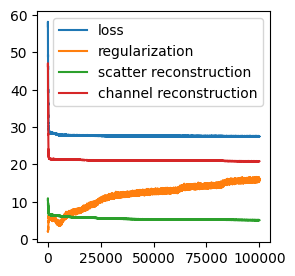

In [ ]:
USE_NORMALIZED_DATA = True

# defining optimizer
optimizer = torch.optim.Adam(
    itertools.chain(*[
        joint_encoder.parameters(), 
        scatter_decoder.parameters(),
        channel_decoder.parameters()
    ]
    )
    , lr=1e-4
)
batch_size = 256

# iteration
n_grad_steps = 100_000
n_mc_samples = 50
iterator = range(n_grad_steps)
pbar = tqdm(iterator)

# storing progress
reg_loss_history = np.zeros((n_grad_steps, ))
channel_rec_loss_history = np.zeros((n_grad_steps, ))
scatter_rec_loss_history = np.zeros((n_grad_steps, ))
loss_history = np.zeros((n_grad_steps, ))
reg_strength = 1e-1

# precomputing indices
indices = np.arange(X_channel.shape[0])

# iterating over gradient steps
for grad_step in iterator:
    # sample batch
    batch_idx = np.random.choice(indices, size=batch_size)
    if USE_NORMALIZED_DATA:
        x_scatter = torch.from_numpy(X_scatter_norm[batch_idx]).to("cuda")
        x_channel = torch.from_numpy(X_channel_norm[batch_idx]).to("cuda")
    else:
        x_scatter = torch.from_numpy(X_scatter[batch_idx]).to("cuda")
        x_channel = torch.from_numpy(X_channel[batch_idx]).to("cuda")


    # creating input for joint encoder
    x = torch.concatenate([x_scatter, x_channel], axis=-1)

    # encoding
    z_params = joint_encoder(x)
    z_mean = z_params["mean"]
    z_covariance = z_params["covariance"]
    noise_samples = torch.randn((n_mc_samples, *z_mean.shape), device=z_mean.device)
    z_samples = z_mean.repeat(n_mc_samples, 1, 1) + noise_samples*z_covariance.repeat(n_mc_samples, 1, 1)

    # decoding
    x_scatter_param = scatter_decoder(z_samples)
    x_scatter_mean = x_scatter_param["mean"]
    x_scatter_std = x_scatter_param["covariance"]
    x_channel_param = channel_decoder(z_samples)
    x_channel_mean = x_channel_param["mean"]
    x_channel_std = x_channel_param["covariance"]
    
    def compute_rec_loss(x, mean, cov):
        x = x.unsqueeze(0)
        dim = mean.shape[-1]
        cov = cov**2
        rec_loss = (
            (0.5 / cov) * torch.sum((x.repeat(n_mc_samples, 1, 1) - mean) ** 2, axis=-1, keepdim=True)
            + 0.5 * torch.log(cov)
            + dim * 0.5 * torch.log(torch.tensor([2 * np.pi], device=mean.device))
        )[:, :, 0].mean()
        return rec_loss
    scatter_rec_loss = compute_rec_loss(x_scatter, x_scatter_mean, x_scatter_std)
    channel_rec_loss = compute_rec_loss(x_channel, x_channel_mean, x_channel_std)

    # compute regularization loss
    reg_loss = -0.5*torch.sum(
        1 + torch.log(z_covariance**2) - z_mean**2 - z_covariance**2, dim=-1
    ).mean()

    loss = reg_loss*reg_strength + channel_rec_loss + scatter_rec_loss
    # print(loss.shape)
    # print(f"loss: {loss.item()}, reg: {reg_loss.item()}, channel_rec: {channel_rec_loss.item()}, scatter_rec: {scatter_rec_loss.item()}")
    # break
    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # logging
    # if (grad_step + 1)%100==0:
    pbar.set_description(f"loss: {loss.item()}, reg: {reg_loss.item()}, channel_rec: {channel_rec_loss.item()}, scatter_rec: {scatter_rec_loss.item()}")
    pbar.update()
    loss_history[grad_step] = loss.item()
    reg_loss_history[grad_step] = reg_loss.item()
    scatter_rec_loss_history[grad_step] = scatter_rec_loss.item()
    channel_rec_loss_history[grad_step] = channel_rec_loss.item()

# plotting
plt.figure(figsize=(3, 3))
plt.plot(loss_history, label="loss")
plt.plot(reg_loss_history, label="regularization")
plt.plot(scatter_rec_loss_history, label="scatter reconstruction")
plt.plot(channel_rec_loss_history, label="channel reconstruction")
plt.legend()


### Sampling States.

In [11]:
num_samples = 100_000
z = torch.randn((num_samples, LATENT_DIM)).to("cuda")

x_scatter_param = scatter_decoder(z)
x_scatter_mean = x_scatter_param["mean"]
x_scatter_std = x_scatter_param["covariance"]

x_channel_param = channel_decoder(z)
x_channel_mean = x_channel_param["mean"]
x_channel_std = x_channel_param["covariance"]

num_samples_per_obs = 100
z = torch.randn((num_samples_per_obs, num_samples, x_channel_mean.shape[1])).to("cuda")
x_channel_samples = x_channel_mean + x_channel_std*z
x_channel_gen = x_channel_samples.mean(0).detach().cpu().numpy()
x_channel_gen = X_channel.std(0, keepdims=True)*x_channel_gen + X_channel.mean(0, keepdims=True)

z = torch.randn((num_samples_per_obs, num_samples, x_scatter_mean.shape[1])).to("cuda")
x_scatter_samples = x_scatter_mean + x_scatter_std*z
x_scatter_gen = x_scatter_samples.mean(0).mean(0).detach().cpu().numpy()
x_scatter_gen = X_scatter.std(0, keepdims=True)*x_scatter_gen + X_scatter.mean(0, keepdims=True)


In [ ]:
from anndata import AnnData
def concatenate_adata_and_plot(
    X, samples, plot_pcs=True, plot_umap=True, subsample_size=0.1, coloring=["dataset_type"], key="X_pca", **kwargs
):
    obs = {"dataset_type": ["Real" for _ in range(adata.shape[0])] + ["Generated" for _ in range(samples.shape[0])], **kwargs}
    # adata_generated = AnnData(X=np.concatenate([adata.obsm[key], samples], axis=0), obs=obs)
    adata_generated = AnnData(X=np.concatenate([X, samples], axis=0), obs=obs)
    adata_generated.obsm[key] = adata_generated.X.copy()

    if plot_umap:
        sc.pp.subsample(adata_generated, subsample_size)
        sc.pp.neighbors(adata_generated)
        sc.tl.umap(adata_generated)
        
    for color in coloring:
        if plot_pcs:
            sc.pl.embedding(adata_generated, basis=key, color=color)
        if plot_umap:
            sc.pl.umap(adata_generated, color=color)
    return adata_generated
adata_generated = concatenate_adata_and_plot(
    X_channel,
    x_channel_gen,
    key="X_rep"
)


loss: 27.510711669921875, reg: 15.808174133300781, channel_rec: 20.874135971069336, scatter_rec: 5.055756568908691: 100%|██████████| 100000/100000 [12:10<00:00, 175.30it/s]